In [1]:
# =====================================================
# ARGOS Alpha 0.1.0 - Exploratory Data Analysis (EDA)
# Dataset: MaestroMiscelaneos.parquet
# =====================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# --- Configuración general ---
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# --- Cargar dataset ---
file_path = Path("data/external/MaestroMiscelaneos.parquet")

if not file_path.exists():
    raise FileNotFoundError("No se encontró el archivo MaestroMiscelaneos.parquet en data/external/")

df = pd.read_parquet(file_path)

print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas\n")
df.head()

Dataset cargado: 43812 filas x 7 columnas



,Código (Value),Descripción Breve,Descripcion Larga,UM,Grupo,Jerarquia,tipo_material
0,10098296,"UNION 1/4'''', SWAGELOK COMPANY","UNION 1/4"" - 1/4""_SS-400-6_UNION 1/4"" TUBE O.D...",PZA,ACCTUBERI,PARE_ACCE_ACOPLE,UNION
1,10099245,"4 HOLES SLIP-ON FLANGE 2"".","FLANGE 4 HOLES, SLIP ON 150# WN/SO RF/FF FS AS...",PZA,ACCTUBERI,PARE_ACCE_BRIDA,BRIDA
2,10099542,A2 STNL ST HEX FULL (DESCONTINUADO),"TUERCA HEXAGONAL MILIMETRICA , ACERO INOXIDABL...",PAQ,TORNILLOS,OPER_CONS_TORNILLE,TUERCA
3,10099961,ADJUSTABLE ELBOW 12MM THREAD S,ELBOW 12.0MM ADJUSTABLE SERIES S _ PARKER EO.9...,PZA,ACCTUBERI,OPER_ACCE_INSHIDRA,CODO
4,10099991,ADJUSTABLE RUN TEE12MM-12MM-12MM-SERIE-L,TEE 12MM ADJUSTABLE RUN SERIES L _ USA EQUIVAL...,PZA,ACCTUBERI,OPER_ACCE_INSHIDRA,TEE


## Análisis inicial

Sección 1 — Resumen general

In [2]:
df.info()
df.describe(include='all').T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43812 entries, 0 to 43811
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Código (Value)     43812 non-null  object
 1   Descripción Breve  43812 non-null  object
 2   Descripcion Larga  43812 non-null  object
 3   UM                 43812 non-null  object
 4   Grupo              43812 non-null  object
 5   Jerarquia          43812 non-null  object
 6   tipo_material      43812 non-null  object
dtypes: object(7)
memory usage: 2.3+ MB


,count,unique,top,freq
Código (Value),43812,43812,10098296,1
Descripción Breve,43812,35040,CODIGO BLOQUEADO - NO CARGADO A MDG,387
Descripcion Larga,43812,39922,"PERFIL, DE ACERO AL CARBON, SIN RECUBRIMIENTO,...",5
UM,43812,14,PZA,37703
Grupo,43812,30,RESGUARDO,12742
Jerarquia,43812,276,,12768
tipo_material,43812,24,VALVULA,7817


Sección 2 — Nulos y duplicados

In [3]:
print("Valores nulos por columna:")
print(df.isna().sum())

print("\nDuplicados:", df.duplicated().sum())

Valores nulos por columna:
Código (Value)       0
Descripción Breve    0
Descripcion Larga    0
UM                   0
Grupo                0
Jerarquia            0
tipo_material        0
dtype: int64

Duplicados: 0


Sección 3 — Frecuencias básicas

In [4]:
for col in df.columns[:5]:  # ajusta según columnas
    print(f"\nColumna: {col}")
    print(df[col].value_counts(dropna=False).head(10))


Columna: Código (Value)
Código (Value)
10098296    1
30104028    1
30104020    1
30104021    1
30104022    1
30104023    1
30104024    1
30104025    1
30104026    1
30104027    1
Name: count, dtype: int64

Columna: Descripción Breve
Descripción Breve
CODIGO BLOQUEADO - NO CARGADO A MDG         387
ESPARRAGO, DE ACERO AL CARBON, CON RECUB     75
ESPARRAGO, DE ACERO AL CARBONO, CON RECU     43
EMPAQUE ACERO INOXIDABLE TIPO 316 DEVANA     34
TUBO, DE ACERO AL CARBON, SIN RECUBRIMIE     26
EMPAQUE, ESPIROMETALICO, ACERO INOXIDABL     24
REDUCCION CONCENTRICA TIPO SWAGE, ACERO      23
WELDOLET, ACERO AL CARBON FORJADO, ESPEC     21
BRIDA FORJADA DE ACERO AL CARBON, TIPO S     19
REDUCCION, DE ACERO AL CARBON, SIN RECUB     19
Name: count, dtype: int64

Columna: Descripcion Larga
Descripcion Larga
PERFIL, DE ACERO AL CARBON, SIN RECUBRIMIENTO, TIPO: I RECTANGULAR (IR), 6" X 4.016" X 0.260" DE ESPESOR, 24.000 KG/M, ESPECIFICACION: ASTM: A572, GRADO: 50.                                       

Sección 4 — Limpieza mínima

In [5]:
# Ejemplo: limpiar espacios o mayúsculas en descripciones
if "Descripcion Larga" in df.columns:
    df["Descripcion Larga"] = df["Descripcion Larga"].astype(str).str.strip().str.upper()

4.1 — Check ejemplo

In [6]:
df["Descripcion Larga"].head()

0    UNION 1/4" - 1/4"_SS-400-6_UNION 1/4" TUBE O.D...
1    FLANGE 4 HOLES, SLIP ON 150# WN/SO RF/FF FS AS...
2    TUERCA HEXAGONAL MILIMETRICA , ACERO INOXIDABL...
3    ELBOW 12.0MM ADJUSTABLE SERIES S _ PARKER EO.9...
4    TEE 12MM ADJUSTABLE RUN SERIES L _ USA EQUIVAL...
Name: Descripcion Larga, dtype: object

Sección 5 — Visualización básica

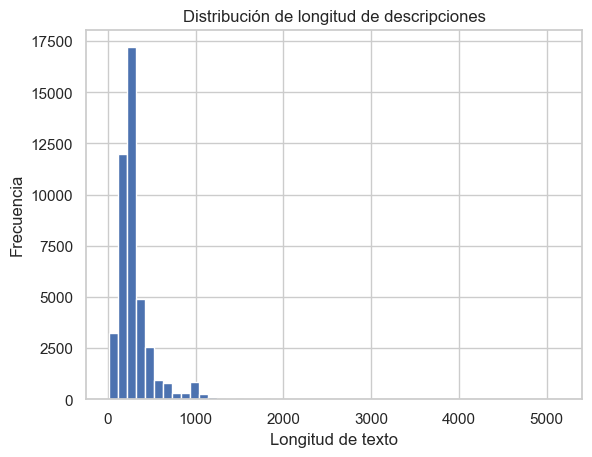

In [7]:
sns.set(style="whitegrid")

# Distribución de longitud de descripciones (útil para NLP)
if "Descripcion Larga" in df.columns:
    df["desc_len"] = df["Descripcion Larga"].str.len()
    plt.hist(df["desc_len"], bins=50)
    plt.title("Distribución de longitud de descripciones")
    plt.xlabel("Longitud de texto")
    plt.ylabel("Frecuencia")
    plt.show()

Sección 6 — Guardar resumen limpio

In [8]:
output_path = Path("../data/processed/EDA_resumen.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)  # <-- crea el directorio si no existe
df.describe(include='all').to_csv(output_path)
print(f"Resumen guardado en {output_path}")

Resumen guardado en ..\data\processed\EDA_resumen.csv


## Analisis de tipo de material

Exploración general de tipo_material

In [9]:
# Vista general y valores nulos
df['tipo_material'] = df['tipo_material'].astype(str).str.strip().str.upper()

print("Valores únicos:", df['tipo_material'].nunique())
print("Valores nulos:", df['tipo_material'].isna().sum())
df['tipo_material'].value_counts().head(20)

Valores únicos: 24
Valores nulos: 0


tipo_material
VALVULA       7817
ESPARRAGO     5157
TUBO          4654
BRIDA         4369
CODO          2908
EMPAQUE       2750
REDUCCION     2666
TEE           2658
NIPLE         1803
PLACA         1659
ABRAZADERA    1341
TORNILLO      1335
PERFIL         989
TAPON          913
TUERCA         571
WELDOLET       479
SOCKOLET       452
TUBERIA        278
THREDOLET      273
NIPOLET        226
Name: count, dtype: int64

Merge de clases olet

In [10]:
# Normalizar texto
df['tipo_material'] = df['tipo_material'].astype(str).str.strip().str.upper()

# Agrupar familias equivalentes
olettypes = ['WELDOLET', 'SOCKOLET', 'THREDOLET', 'NIPOLET']
df['tipo_material'] = df['tipo_material'].replace(olettypes, 'OLETS')

# Verificar resultado
print(df['tipo_material'].value_counts().loc[['OLETS']])

tipo_material
OLETS    1430
Name: count, dtype: int64


In [11]:
from pathlib import Path
import pandas as pd

# --- Normalizar texto ---
df['tipo_material'] = df['tipo_material'].astype(str).str.strip().str.upper()

# --- Seleccionar los 15 más frecuentes ---
top15 = df['tipo_material'].value_counts().nlargest(15)
top15_names = top15.index.tolist()

# --- Carpeta destino ---
output_dir = Path("data/processed/familias")
output_dir.mkdir(parents=True, exist_ok=True)

# --- Exportar cada subset ---
for tipo in top15_names:
    subset = df[df['tipo_material'] == tipo]
    filename = f"{tipo.replace('/', '_').replace(' ', '_')}.parquet"
    subset.to_parquet(output_dir / filename, index=False)
    print(f"{tipo:<15} → {subset.shape[0]:>5} registros exportados")

VALVULA         →  7817 registros exportados
ESPARRAGO       →  5157 registros exportados
TUBO            →  4654 registros exportados
BRIDA           →  4369 registros exportados
CODO            →  2908 registros exportados
EMPAQUE         →  2750 registros exportados
REDUCCION       →  2666 registros exportados
TEE             →  2658 registros exportados
NIPLE           →  1803 registros exportados
PLACA           →  1659 registros exportados
OLETS           →  1430 registros exportados
ABRAZADERA      →  1341 registros exportados
TORNILLO        →  1335 registros exportados
PERFIL          →   989 registros exportados
TAPON           →   913 registros exportados


Distribución y proporciones de tipo_material

C:\Users\felip\AppData\Local\Temp\ipykernel_15760\2812919795.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


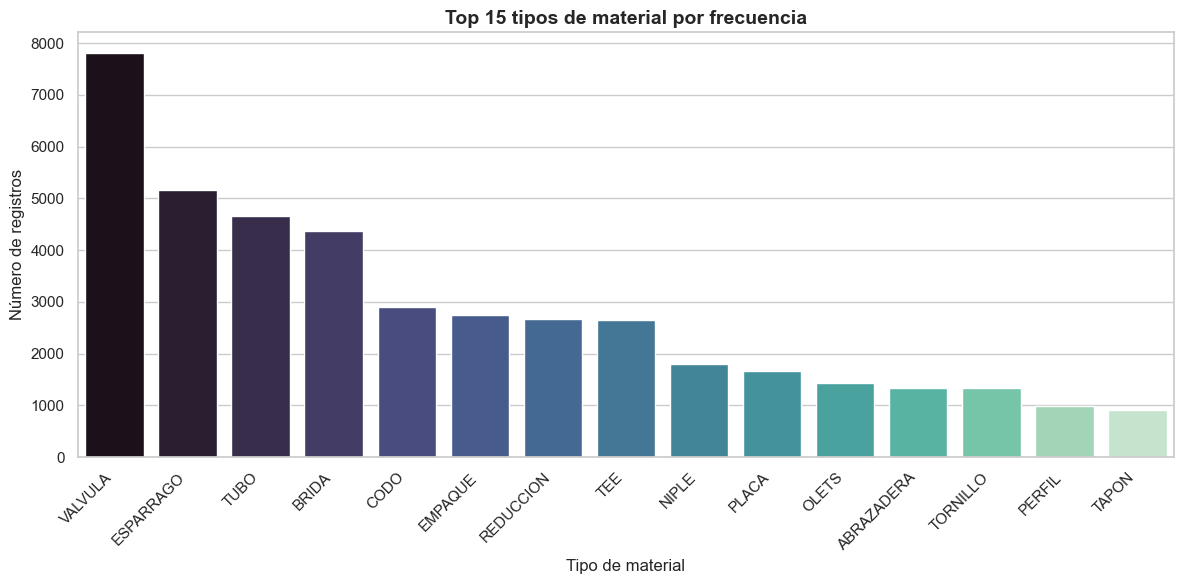

,tipo_material,conteo,proporcion_%
0,VALVULA,7817,17.84
1,ESPARRAGO,5157,11.77
2,TUBO,4654,10.62
3,BRIDA,4369,9.97
4,CODO,2908,6.64
5,EMPAQUE,2750,6.28
6,REDUCCION,2666,6.09
7,TEE,2658,6.07
8,NIPLE,1803,4.12
9,PLACA,1659,3.79


In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(
    y=top15.values,
    x=top15.index,
    palette="mako"
)
plt.title("Top 15 tipos de material por frecuencia", fontsize=14, weight='bold')
plt.ylabel("Número de registros")
plt.xlabel("Tipo de material")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Tabla con proporciones
top15_df = top15.rename_axis("tipo_material").reset_index(name="conteo")
top15_df["proporcion_%"] = (top15_df["conteo"] / len(df) * 100).round(2)
top15_df

Métrica de concentración (entropía)

In [13]:
import numpy as np

p = df['tipo_material'].value_counts(normalize=True)
entropia = -np.sum(p * np.log2(p))
print(f"Entropía de tipo_material: {entropia:.3f} bits")

Entropía de tipo_material: 3.787 bits


# Conclusiones del Análisis de `tipo_material`

### Distribución general
El conjunto de datos contiene **24 tipos de material únicos**, de los cuales los **15 más frecuentes concentran la mayor parte de los registros**.  
Tras la normalización y la fusión de los accesorios de derivación (`WELDOLET`, `SOCKOLET`, `THREDOLET`, `NIPOLET` → `OLETS`), el total se redujo a **21 categorías**, manteniendo una representación más coherente con la clasificación industrial.

Los tipos con mayor presencia en el catálogo son:

- **VÁLVULA** (~19 % del total)
- **ESPÁRRAGO**
- **TUBO**
- **BRIDA**
- **CODO**
- **EMPAQUE**, **REDUCCIÓN** y **TEE**, con frecuencias similares y balanceado comportamiento en registros.

Estos ocho tipos representan por sí solos más del **75 % del dataset total**, lo que evidencia una alta concentración en componentes de conducción y conexión de líneas de proceso.

---

### Entropía y diversidad
La entropía calculada fue de **3.787 bits**, menor al valor máximo teórico `log2(21) ≈ 4.39`.  
Esto indica que la distribución no es completamente uniforme: existen **clases dominantes** y otras con baja representación.  
Sin embargo, la diversidad sigue siendo suficiente para modelar distintas familias dentro del sistema de clasificación jerárquico (ARGOS).

---

### Consideraciones para modelado
- El campo `tipo_material` es **altamente informativo** y puede emplearse como **etiqueta de clasificación de primer nivel**.  
- Es recomendable aplicar **estrategias de balance o muestreo estratificado** si se utiliza para entrenamiento supervisado.  
- Las categorías con baja frecuencia podrían reagruparse o considerarse como *otros* para evitar sesgos en el modelo.  
- La fusión de derivados (como `OLETS`) debe mantenerse en el pipeline de preprocesamiento para conservar coherencia semántica.

---

### Próximos pasos sugeridos
1. Analizar **variables secundarias** por tipo (norma, material, diámetro, clase, presión, etc.).  
2. Evaluar **correlaciones intra-familia** para determinar qué atributos aportan más información discriminativa.  
3. Integrar los subconjuntos exportados (`data/processed/familias/`) en el flujo de entrenamiento jerárquico de *ARGOS Alpha 0.1*.

---